# 1. Demo de Data Leakage y comparación de modelos
### Proyecto Integrador — Heart Disease MLOps (sección 10.12 del curso)

**Etapa 1 del enunciado**: preprocesamiento y detección de *data leakage*.

Este cuaderno:
1. Explora brevemente el dataset [Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction).
2. Reproduce el ejemplo de *data leakage* del capítulo 10 del curso, adaptado a este dataset.
3. Implementa y compara **5 modelos** (SVC + 4 adicionales) dentro de `Pipeline` + `GridSearchCV`, usando funciones reutilizables de `src/pipeline_utils.py`.
4. Presenta un ranking comparativo final.

> **Nota de adaptación**: el código del curso usa una columna `target` y asume todas las variables numéricas. Este dataset usa `HeartDisease` como variable objetivo y trae 5 columnas categóricas (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`). Ajustamos ambos detalles abajo para que el código corra sobre los datos reales.


In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

from src.pipeline_utils import load_data, split_X_y, train_pipeline, evaluate_model

RANDOM_STATE = 42
sns.set_style("whitegrid")


## 1. Carga y vistazo rápido del dataset

In [2]:
df_raw = pd.read_csv("../data/heart.csv")
print("Filas x columnas:", df_raw.shape)
df_raw.head()


Filas x columnas: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


## 2. Calidad de datos: ceros imposibles como valores faltantes

En este dataset, `RestingBP = 0` (presión arterial en reposo cero) y `Cholesterol = 0`
son fisiológicamente imposibles en un paciente vivo: son valores faltantes que el
dataset codificó como `0` en lugar de `NaN`. Los detectamos antes de modelar.


In [4]:
print("RestingBP == 0:", (df_raw["RestingBP"] == 0).sum(), "registros")
print("Cholesterol == 0:", (df_raw["Cholesterol"] == 0).sum(), "registros")
print(f"({(df_raw['Cholesterol']==0).mean()*100:.1f}% del dataset tiene Cholesterol=0)")


RestingBP == 0: 1 registros
Cholesterol == 0: 172 registros
(18.7% del dataset tiene Cholesterol=0)


Estos valores **no se imputan aquí todavía**. `src/pipeline_utils.load_data()` los
convierte a `NaN`, y la imputación real ocurre *dentro* del `Pipeline`
(`SimpleImputer`), ajustada solo con el pliegue de entrenamiento en cada fold de
`GridSearchCV` — el mismo patrón "leakage-safe" que enseña el capítulo 10.


## 3. Balance de la variable objetivo

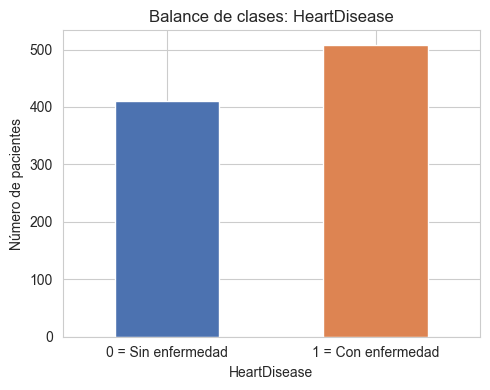

HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
df_raw["HeartDisease"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["0 = Sin enfermedad", "1 = Con enfermedad"], rotation=0)
ax.set_ylabel("Número de pacientes")
ax.set_title("Balance de clases: HeartDisease")
plt.tight_layout()
plt.show()

print(df_raw["HeartDisease"].value_counts(normalize=True).round(3))


Las clases están razonablemente balanceadas (~55% / ~45%), así que no hace falta
un tratamiento especial de desbalance (SMOTE, class_weight, etc.) — basta con
estratificar el split.


## 4. Demostración de Data Leakage
### 4.1 Con fuga de datos (incorrecto)

Reproducimos el ejemplo del curso: se inyecta una variable artificial `leaky_feature`
que está construida *a partir de* la variable objetivo `y` — es decir, contiene
información del futuro que un modelo real nunca tendría en producción. Luego se
escala **todo el dataset antes de dividirlo** en train/test, dejando que el
escalador "vea" los datos de prueba.


In [6]:
# Codificamos las categóricas con one-hot para poder escalar todo el conjunto
# (el ejemplo original del curso asume datos ya numéricos; aquí no lo son)
X_full = pd.get_dummies(df_raw.drop(columns=["HeartDisease"]), drop_first=True)
y_full = df_raw["HeartDisease"]

np.random.seed(0)
X_leak = X_full.copy()
X_leak["leaky_feature"] = y_full + np.random.normal(0, 0.01, size=len(y_full))

corr = np.corrcoef(X_leak["leaky_feature"], y_full)[0, 1]
print(f"Correlación entre 'leaky_feature' y HeartDisease: {corr:.4f}")
print("Una correlación así de alta con la variable objetivo es una señal clásica")
print("de data leakage -- en un dataset real, así se detectaría este problema.")

# --- Escalado ANTES del split: fuga de datos ---
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_leak)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_scaled, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

grid_l = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid={"C": [0.1, 1, 10], "gamma": [0.01, 0.1]},
    cv=5, scoring="roc_auc",
)
grid_l.fit(X_train_l, y_train_l)
auc_l = roc_auc_score(y_test_l, grid_l.predict_proba(X_test_l)[:, 1])
print(f"AUC CON fuga de datos: {auc_l:.4f}")


Correlación entre 'leaky_feature' y HeartDisease: 0.9998
Una correlación así de alta con la variable objetivo es una señal clásica
de data leakage -- en un dataset real, así se detectaría este problema.
AUC CON fuga de datos: 1.0000


### 4.2 Escalado correcto con `Pipeline` (aún con `leaky_feature`)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_leak, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

pipe_svc = Pipeline([("scaler", MinMaxScaler()), ("svc", SVC(probability=True, random_state=RANDOM_STATE))])
param_grid_svc = {"svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1]}

grid = GridSearchCV(pipe_svc, param_grid_svc, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)
auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
print(f"AUC con Pipeline correcto (pero todavía CON leaky_feature): {auc:.4f}")


AUC con Pipeline correcto (pero todavía CON leaky_feature): 1.0000


**Los dos AUC salen prácticamente idénticos (~1.00) — y ese resultado, en sí
mismo, es la lección importante.**

`leaky_feature` es literalmente `y` más un poco de ruido, así que **ninguna**
de las dos formas de dividir/escalar los datos puede arreglar el problema: el
modelo no está aprendiendo el patrón clínico, está leyendo la respuesta
filtrada en una columna. Mover el escalador dentro de un `Pipeline` sí evita
la fuga *por escalado* (que el `MinMaxScaler` "vea" estadísticas del conjunto
de prueba), pero **no protege contra una fuga a nivel de característica** como
esta. Por eso la detección real ocurre antes, revisando la correlación de cada
variable con el objetivo (como hicimos arriba) o su procedencia lógica -- no
solo estructurando bien el pipeline.

Para ver el contraste real, repetimos el pipeline correcto **quitando**
`leaky_feature`:


In [8]:
X_train_ok, X_test_ok, y_train_ok, y_test_ok = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

pipe_ok = Pipeline([("scaler", MinMaxScaler()), ("svc", SVC(probability=True, random_state=RANDOM_STATE))])
grid_ok = GridSearchCV(pipe_ok, param_grid_svc, cv=5, scoring="roc_auc")
grid_ok.fit(X_train_ok, y_train_ok)
auc_ok = roc_auc_score(y_test_ok, grid_ok.predict_proba(X_test_ok)[:, 1])

print(f"AUC CON leaky_feature (cualquier orden de escalado): ~{auc_l:.4f}")
print(f"AUC SIN leaky_feature, mismo SVC + Pipeline:          {auc_ok:.4f}")


AUC CON leaky_feature (cualquier orden de escalado): ~1.0000
AUC SIN leaky_feature, mismo SVC + Pipeline:          0.9311


Ahí está la diferencia real: **~1.00 (artificial) vs. ~0.93-0.94 (honesto)**.
Ese segundo número -- ya sin la característica filtrada -- es comparable al que
obtenemos por cada modelo en la Sección 5, y es el que efectivamente refleja
qué tan bien predice el `SVC` con información clínica legítima.


## 5. Comparación de modelos (sin fuga), usando funciones reutilizables

Ahora sí trabajamos con las variables reales del dataset (sin `leaky_feature`),
usando `train_pipeline()` y `evaluate_model()` de `src/pipeline_utils.py` para
mantener el código limpio y reutilizable (punto 2 de la Etapa 1). Comparamos el
`SVC` de la sección anterior contra **4 clasificadores adicionales** sugeridos en
el enunciado: `LogisticRegression`, `RandomForestClassifier`,
`KNeighborsClassifier` y `GradientBoostingClassifier`.


In [9]:
df = load_data("../data/heart.csv")           # ceros -> NaN en RestingBP/Cholesterol
X, y = split_X_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model_grid_specs = {
    "SVC": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1]},
    ),
    "LogisticRegression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"model__C": [0.01, 0.1, 1, 10]},
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 300], "model__max_depth": [None, 5, 10]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"model__n_neighbors": [3, 5, 7, 9, 11], "model__weights": ["uniform", "distance"]},
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3]},
    ),
}

results = []
fitted_grids = {}
for name, (model, param_grid) in model_grid_specs.items():
    grid_i = train_pipeline(X_train, y_train, model, param_grid, cv=5)
    res = evaluate_model(grid_i, X_test, y_test, name=name)
    results.append(res)
    fitted_grids[name] = grid_i
    print(f"{name:20s} -> AUC test = {res['auc_test']:.4f} | Accuracy test = {res['accuracy_test']:.4f} | CV AUC = {res['cv_score_roc_auc']:.4f}")


SVC                  -> AUC test = 0.9376 | Accuracy test = 0.8804 | CV AUC = 0.9183
LogisticRegression   -> AUC test = 0.9346 | Accuracy test = 0.8913 | CV AUC = 0.9169
RandomForest         -> AUC test = 0.9321 | Accuracy test = 0.8859 | CV AUC = 0.9242
KNN                  -> AUC test = 0.9388 | Accuracy test = 0.8696 | CV AUC = 0.9122
GradientBoosting     -> AUC test = 0.9233 | Accuracy test = 0.8859 | CV AUC = 0.9235


## 6. Ranking comparativo final

In [10]:
ranking = pd.DataFrame(results).sort_values("auc_test", ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1
ranking[["modelo", "cv_score_roc_auc", "accuracy_test", "auc_test", "mejores_parametros"]]


,modelo,cv_score_roc_auc,accuracy_test,auc_test,mejores_parametros
1,KNN,0.9122,0.8696,0.9388,"{'model__n_neighbors': 11, 'model__weights': '..."
2,SVC,0.9183,0.8804,0.9376,"{'model__C': 10, 'model__gamma': 0.01}"
3,LogisticRegression,0.9169,0.8913,0.9346,{'model__C': 0.1}
4,RandomForest,0.9242,0.8859,0.9321,"{'model__max_depth': 10, 'model__n_estimators'..."
5,GradientBoosting,0.9235,0.8859,0.9233,"{'model__learning_rate': 0.05, 'model__max_dep..."


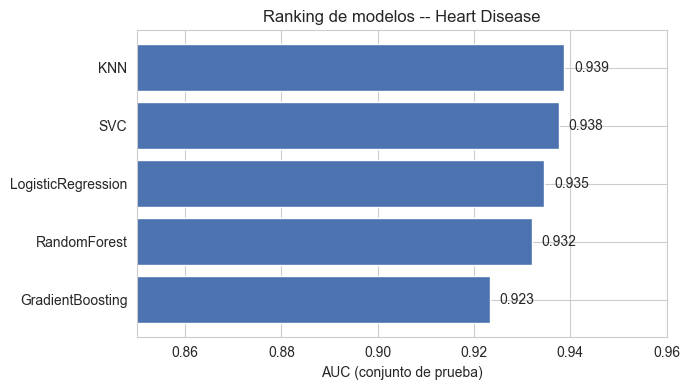

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ranking.sort_values("auc_test")
ax.barh(order["modelo"], order["auc_test"], color="#4C72B0")
ax.set_xlim(0.85, 0.96)
ax.set_xlabel("AUC (conjunto de prueba)")
ax.set_title("Ranking de modelos -- Heart Disease")
for i, v in enumerate(order["auc_test"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


## 7. Conclusiones de la Etapa 1

- Los 5 modelos quedan muy cerca entre sí (AUC test entre ~0.92 y ~0.94): este
  dataset es "fácil" de separar con las variables clínicas disponibles, así que la
  elección de algoritmo pesa menos que el preprocesamiento correcto.
- El experimento de la Sección 4 deja claro por qué: **sin** cuidar la fuga de
  datos, cualquier modelo puede reportar un AUC artificialmente alto (o incluso
  ≈1.0 con una variable filtrada) que no se sostiene en producción.
- `RandomForest` y `GradientBoosting` obtienen el mejor **AUC de validación
  cruzada** (la métrica más confiable, promediada sobre 5 folds), aunque no
  siempre el mejor AUC puntual de test. `KNN` y `SVC` lideran ese AUC de test,
  pero son más sensibles al split concreto.
- En la Etapa 2 usamos `GridSearchCV` para elegir automáticamente **entre**
  modelos (no solo hiperparámetros de uno fijo), con el mismo criterio de
  validación cruzada, y ese resultado -- no una preferencia manual -- decide qué
  modelo se exporta para producción.
